In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [10]:
!pip install 

  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 12.5 MB/s  0:00:002.9 MB/s eta 0:00:01:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 12.9 MB/s  0:00:004.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 13.0 MB/s  0:00:003.9 MB/s eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [2]:
clean = pd.read_csv("monkeypox_project_data_cleaning/data/processed/monkeypox_clean.csv")
clean.head()

,patient_id,systemic_illness,rectal_pain,sore_throat,penile_oedema,oral_lesions,solitary_lesion,swollen_tonsils,hiv_infection,sexually_transmitted_infection,monkeypox
0,P0,none_reported_or_missing,0,1,1,1,0,1,0,0,0
1,P1,fever,1,0,1,1,0,0,1,0,1
2,P2,fever,0,1,1,0,0,0,1,0,1
3,P3,none_reported_or_missing,1,0,0,0,1,1,1,0,1
4,P4,swollen_lymph_nodes,1,1,1,0,0,1,1,0,1


In [4]:
model_ready = pd.read_csv("monkeypox_project_data_cleaning/data/processed/monkeypox_model_ready.csv")
model_ready.head()

,rectal_pain,sore_throat,penile_oedema,oral_lesions,solitary_lesion,swollen_tonsils,hiv_infection,sexually_transmitted_infection,systemic_illness_fever,systemic_illness_muscle_aches_and_pain,systemic_illness_none_reported_or_missing,systemic_illness_swollen_lymph_nodes,monkeypox
0,0,1,1,1,0,1,0,0,0,0,1,0,0
1,1,0,1,1,0,0,1,0,1,0,0,0,1
2,0,1,1,0,0,0,1,0,1,0,0,0,1
3,1,0,0,0,1,1,1,0,0,0,1,0,1
4,1,1,1,0,0,1,1,0,0,0,0,1,1


In [5]:
test = pd.read_csv("monkeypox_project_data_cleaning/data/processed/test.csv")
train = pd.read_csv("monkeypox_project_data_cleaning/data/processed/train.csv")

In [6]:
test.head()

,rectal_pain,sore_throat,penile_oedema,oral_lesions,solitary_lesion,swollen_tonsils,hiv_infection,sexually_transmitted_infection,systemic_illness_fever,systemic_illness_muscle_aches_and_pain,systemic_illness_none_reported_or_missing,systemic_illness_swollen_lymph_nodes,monkeypox
0,0,1,0,0,1,0,0,1,0,1,0,0,1
1,1,0,1,0,0,1,1,0,0,0,1,0,1
2,0,0,0,0,1,1,1,0,0,1,0,0,1
3,1,0,0,1,0,1,0,1,0,1,0,0,0
4,1,0,1,0,0,1,1,0,0,0,0,1,1


In [7]:
train.head()

,rectal_pain,sore_throat,penile_oedema,oral_lesions,solitary_lesion,swollen_tonsils,hiv_infection,sexually_transmitted_infection,systemic_illness_fever,systemic_illness_muscle_aches_and_pain,systemic_illness_none_reported_or_missing,systemic_illness_swollen_lymph_nodes,monkeypox
0,0,1,0,1,0,0,1,1,0,0,1,0,0
1,0,0,0,0,1,0,1,1,0,0,0,1,1
2,1,0,1,1,0,1,0,1,0,1,0,0,1
3,1,0,1,0,0,1,0,0,0,0,1,0,1
4,1,1,0,1,0,0,1,1,1,0,0,0,1


Train shape: (20000, 12)
Test shape: (5000, 12)
Target column: monkeypox

Class balance:
monkeypox
1    12727
0     7273
Name: count, dtype: int64
monkeypox
1    0.63635
0    0.36365
Name: proportion, dtype: float64


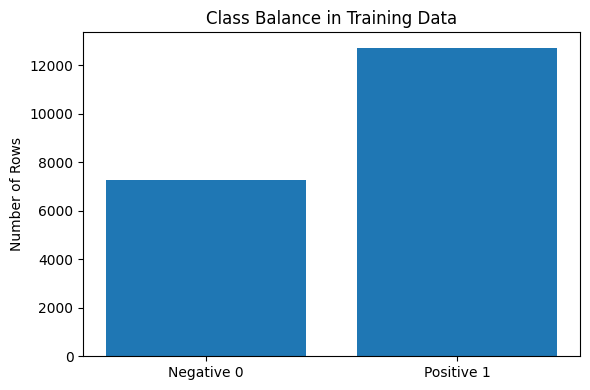


Top feature values by positive rate:


,feature_value,positive_rate
17,systemic_illness_fever = 1,0.746945
23,systemic_illness_swollen_lymph_nodes = 1,0.737201
13,hiv_infection = 1,0.706040
1,rectal_pain = 1,0.704506
15,sexually_transmitted_infection = 1,0.693459
18,systemic_illness_muscle_aches_and_pain = 0,0.673674
20,systemic_illness_none_reported_or_missing = 0,0.669795
5,penile_oedema = 1,0.667097
3,sore_throat = 1,0.666137
7,oral_lesions = 1,0.661128


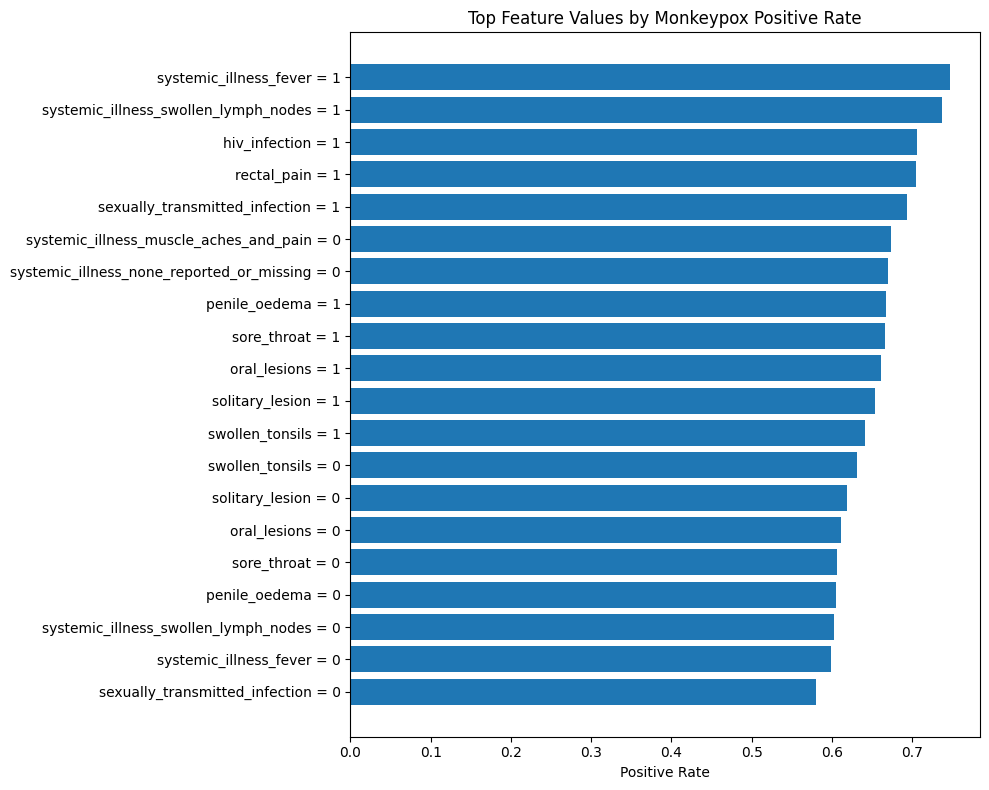


Dummy Baseline
Accuracy: 0.6364
ROC-AUC:  0.5000
PR-AUC:   0.6364
Confusion Matrix:
[[   0 1818]
 [   0 3182]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1818
           1       0.64      1.00      0.78      3182

    accuracy                           0.64      5000
   macro avg       0.32      0.50      0.39      5000
weighted avg       0.41      0.64      0.49      5000


Logistic Regression
Accuracy: 0.6868
ROC-AUC:  0.7044
PR-AUC:   0.7869
Confusion Matrix:
[[ 664 1154]
 [ 412 2770]]
              precision    recall  f1-score   support

           0       0.62      0.37      0.46      1818
           1       0.71      0.87      0.78      3182

    accuracy                           0.69      5000
   macro avg       0.66      0.62      0.62      5000
weighted avg       0.67      0.69      0.66      5000


Balanced Logistic Regression
Accuracy: 0.6428
ROC-AUC:  0.7043
PR-AUC:   0.7869
Confusion Matrix:
[[1153  665]
 [112

/opt/miniconda3/envs/CS189/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/CS189/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/CS189/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

Accuracy: 0.6784
ROC-AUC:  0.6781
PR-AUC:   0.7608
Confusion Matrix:
[[ 592 1226]
 [ 382 2800]]
              precision    recall  f1-score   support

           0       0.61      0.33      0.42      1818
           1       0.70      0.88      0.78      3182

    accuracy                           0.68      5000
   macro avg       0.65      0.60      0.60      5000
weighted avg       0.66      0.68      0.65      5000


Extra Trees
Accuracy: 0.6762
ROC-AUC:  0.6780
PR-AUC:   0.7598
Confusion Matrix:
[[ 626 1192]
 [ 427 2755]]
              precision    recall  f1-score   support

           0       0.59      0.34      0.44      1818
           1       0.70      0.87      0.77      3182

    accuracy                           0.68      5000
   macro avg       0.65      0.61      0.60      5000
weighted avg       0.66      0.68      0.65      5000


Gradient Boosting
Accuracy: 0.6896
ROC-AUC:  0.7029
PR-AUC:   0.7875
Confusion Matrix:
[[ 639 1179]
 [ 373 2809]]
              precision   

,model,accuracy,roc_auc,pr_auc
6,Hist Gradient Boosting,0.6898,0.698199,0.783608
5,Gradient Boosting,0.6896,0.702875,0.787521
7,Neural Network,0.6888,0.695560,0.780549
1,Logistic Regression,0.6868,0.704417,0.786873
3,Random Forest,0.6784,0.678085,0.760755
4,Extra Trees,0.6762,0.677962,0.759804
2,Balanced Logistic Regression,0.6428,0.704328,0.786866
0,Dummy Baseline,0.6364,0.500000,0.636400


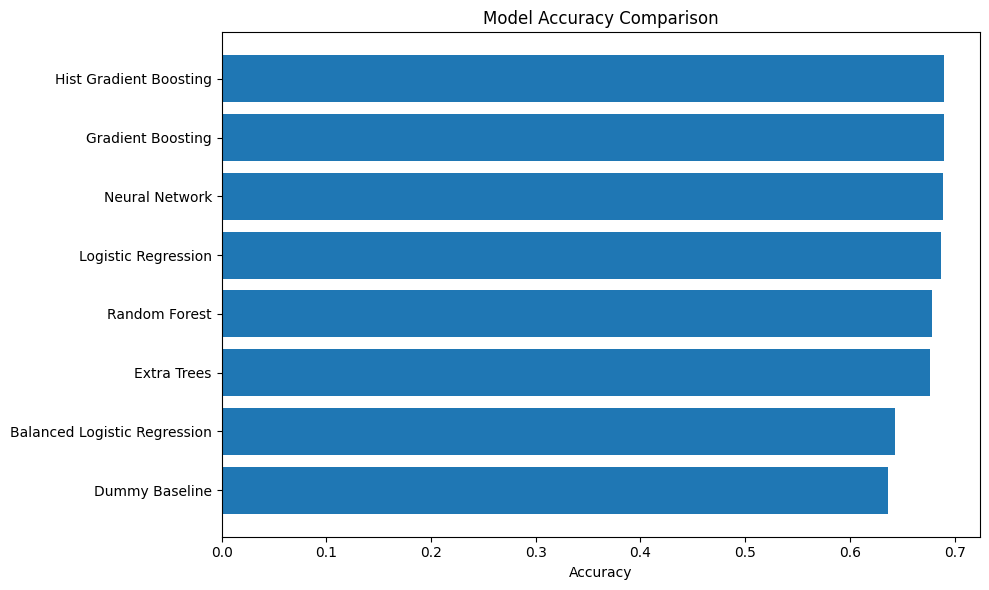

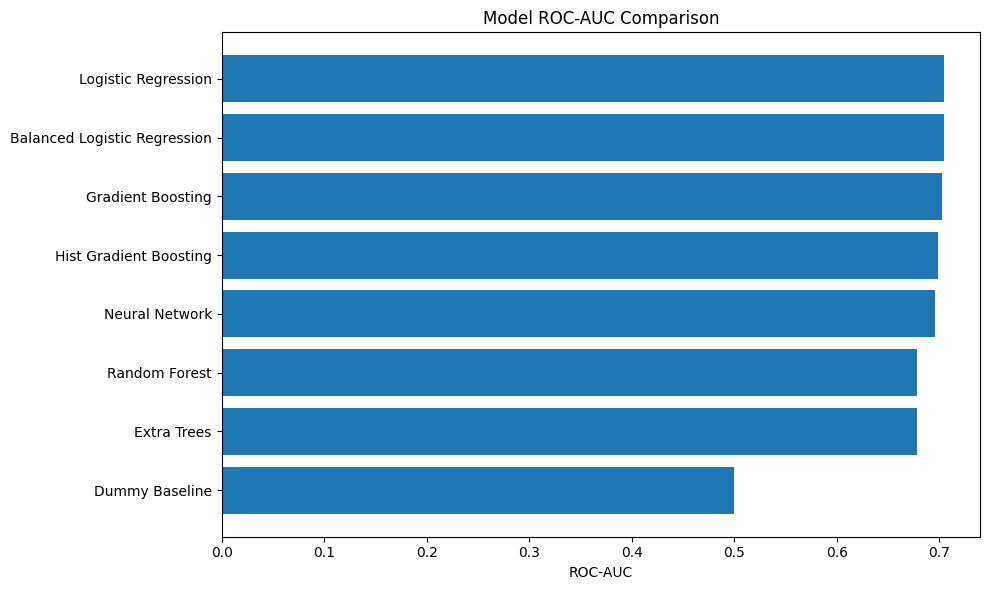

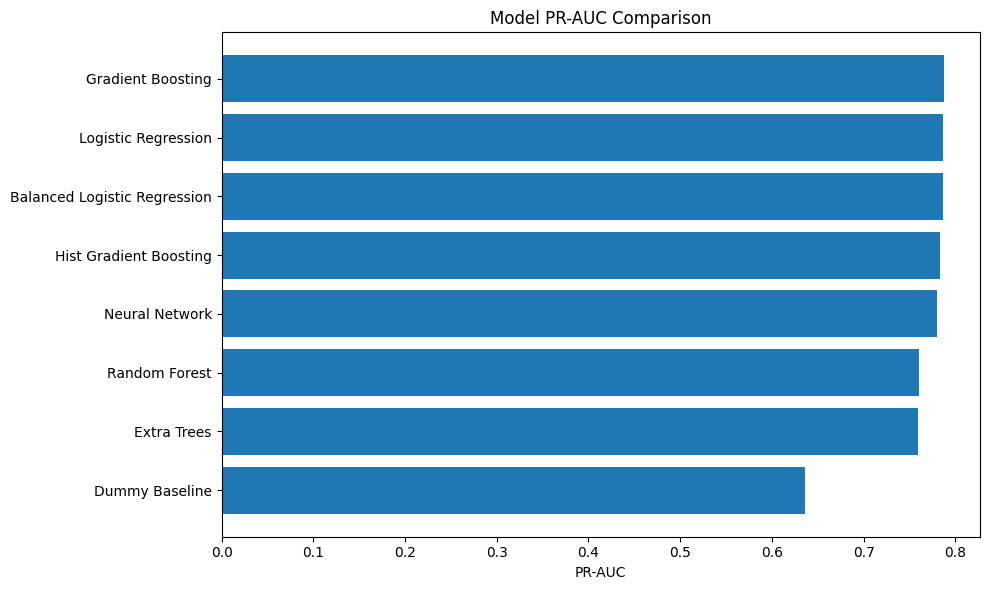


Best model by accuracy: Hist Gradient Boosting
Best accuracy: 0.6898


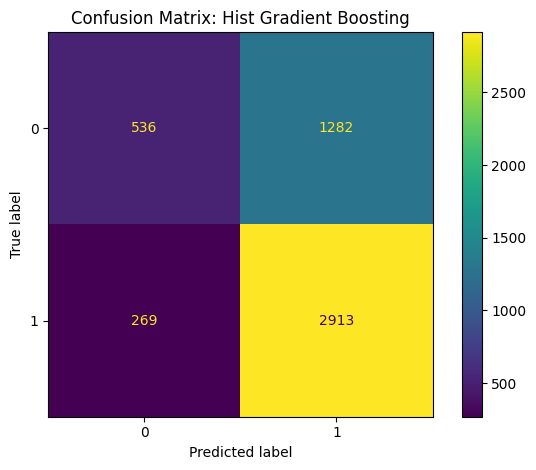

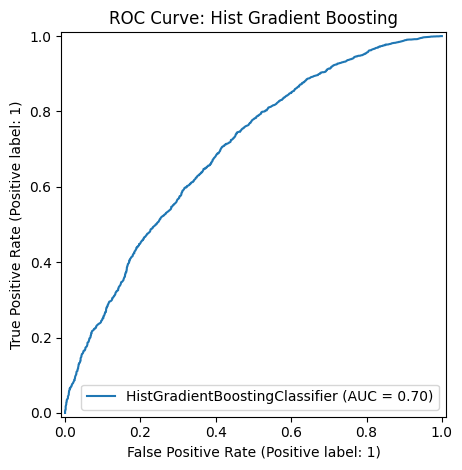

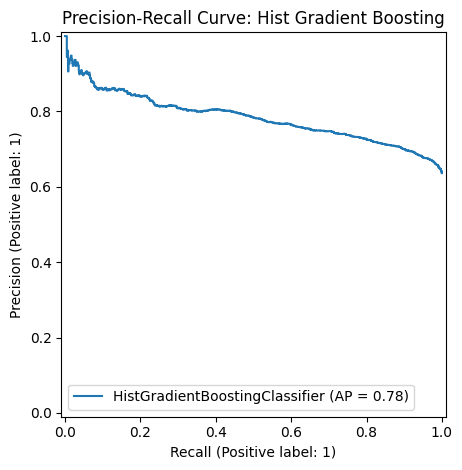


Top feature importances:


,feature,importance
0,rectal_pain,0.147404
6,hiv_infection,0.146675
7,sexually_transmitted_infection,0.115041
9,systemic_illness_muscle_aches_and_pain,0.088237
10,systemic_illness_none_reported_or_missing,0.081117
8,systemic_illness_fever,0.074715
11,systemic_illness_swollen_lymph_nodes,0.074254
1,sore_throat,0.061449
3,oral_lesions,0.056368
4,solitary_lesion,0.055342


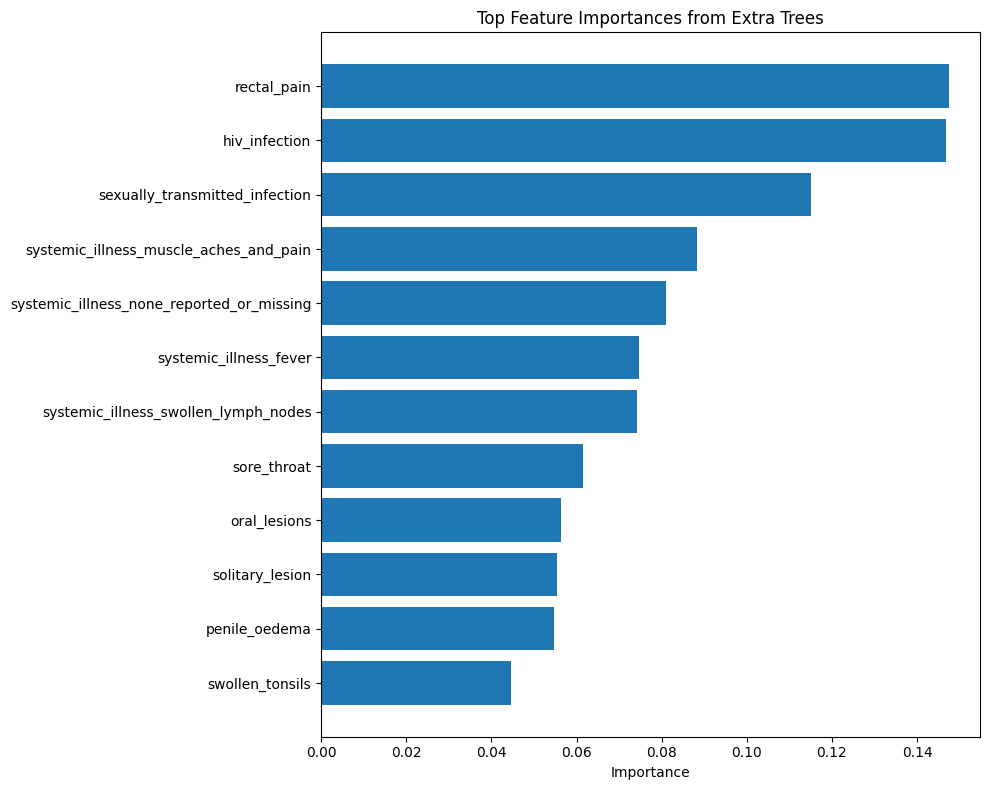


Best threshold for accuracy:


threshold    0.530
accuracy     0.693
Name: 48, dtype: float64

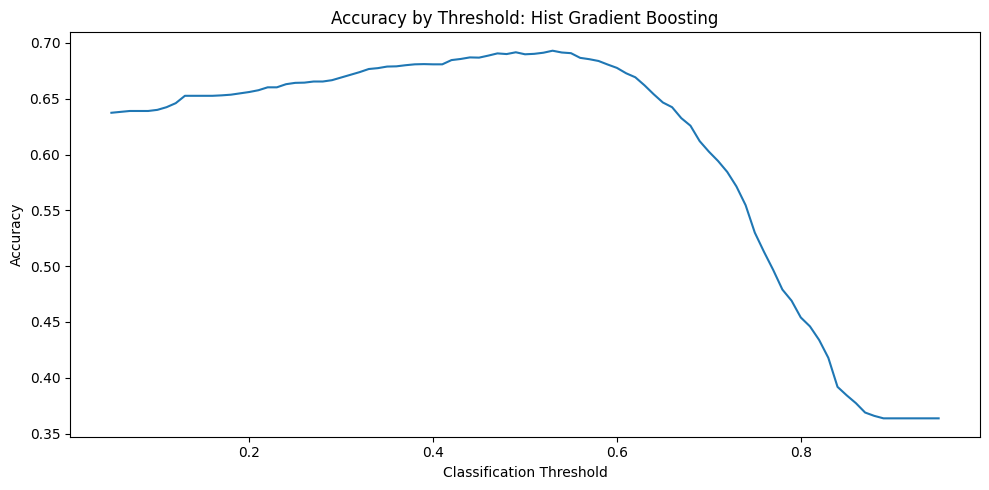


Final tuned-threshold result:
Final model: Hist Gradient Boosting
Best threshold: 0.53
Final accuracy: 0.693

Confusion Matrix:
[[ 628 1190]
 [ 345 2837]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.35      0.45      1818
           1       0.70      0.89      0.79      3182

    accuracy                           0.69      5000
   macro avg       0.67      0.62      0.62      5000
weighted avg       0.68      0.69      0.66      5000


Saved model results to: /Users/sohumpulijal/Documents/school/CS189/project/model_results.csv


In [19]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# 1. Load data
# ============================================================

BASE_DIR = Path("/Users/sohumpulijal/Documents/school/CS189/project")

TRAIN_PATH = BASE_DIR / "monkeypox_project_data_cleaning" / "data" / "processed" / "train.csv"
TEST_PATH = BASE_DIR / "monkeypox_project_data_cleaning" / "data" / "processed" / "test.csv"
TARGET_PATH = BASE_DIR / "monkeypox_project_data_cleaning" / "data" / "processed" / "target_column.txt"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

with open(TARGET_PATH, "r") as file:
    target_column = file.read().strip()

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Target column:", target_column)

# ============================================================
# 2. Class balance
# ============================================================

print("\nClass balance:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative 0", "Positive 1"], class_counts.values)
plt.title("Class Balance in Training Data")
plt.ylabel("Number of Rows")
plt.tight_layout()
plt.show()

# ============================================================
# 3. Positive rate by feature value
# ============================================================

feature_rates = []

for column in X_train.columns:
    temp = train_df[[column, target_column]].copy()

    if temp[column].nunique() <= 10:
        grouped = temp.groupby(column)[target_column].mean()

        for value, positive_rate in grouped.items():
            feature_rates.append({
                "feature_value": f"{column} = {value}",
                "positive_rate": positive_rate
            })

feature_rates_df = pd.DataFrame(feature_rates).sort_values(
    by="positive_rate",
    ascending=False
)

print("\nTop feature values by positive rate:")
display(feature_rates_df.head(20))

top_rates = feature_rates_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_rates["feature_value"], top_rates["positive_rate"])
plt.xlabel("Positive Rate")
plt.title("Top Feature Values by Monkeypox Positive Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# 4. Define models
# ============================================================

models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "Balanced Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ),

    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# ============================================================
# 5. Train and evaluate models
# ============================================================

results = []
trained_models = {}

for model_name, model in models.items():
    print("\n==============================")
    print(model_name)
    print("==============================")

    model.fit(X_train, y_train)
    trained_models[model_name] = model

    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, probabilities)
        pr_auc = average_precision_score(y_test, probabilities)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print(classification_report(y_test, predictions))

    results.append({
        "model": model_name,
        "accuracy": accuracy,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })

results_df = pd.DataFrame(results).sort_values(
    by="accuracy",
    ascending=False
)

print("\nModel comparison:")
display(results_df)

# ============================================================
# 6. Graph model accuracy
# ============================================================

accuracy_df = results_df.sort_values(by="accuracy", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(accuracy_df["model"], accuracy_df["accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

# ============================================================
# 7. Graph ROC-AUC
# ============================================================

roc_df = results_df.dropna(subset=["roc_auc"]).sort_values(
    by="roc_auc",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(roc_df["model"], roc_df["roc_auc"])
plt.xlabel("ROC-AUC")
plt.title("Model ROC-AUC Comparison")
plt.tight_layout()
plt.show()

# ============================================================
# 8. Graph PR-AUC
# ============================================================

pr_df = results_df.dropna(subset=["pr_auc"]).sort_values(
    by="pr_auc",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(pr_df["model"], pr_df["pr_auc"])
plt.xlabel("PR-AUC")
plt.title("Model PR-AUC Comparison")
plt.tight_layout()
plt.show()

# ============================================================
# 9. Pick best model by accuracy
# ============================================================

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("\nBest model by accuracy:", best_model_name)
print("Best accuracy:", results_df.iloc[0]["accuracy"])

best_predictions = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, best_predictions)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

# ============================================================
# 10. ROC and precision-recall curves for best model
# ============================================================

if hasattr(best_model, "predict_proba"):
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f"ROC Curve: {best_model_name}")
    plt.tight_layout()
    plt.show()

    PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f"Precision-Recall Curve: {best_model_name}")
    plt.tight_layout()
    plt.show()

# ============================================================
# 11. Feature importance using Extra Trees
# ============================================================

tree_model = trained_models["Extra Trees"]

importances_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop feature importances:")
display(importances_df.head(20))

top_importances = importances_df.head(20).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(top_importances["feature"], top_importances["importance"])
plt.xlabel("Importance")
plt.title("Top Feature Importances from Extra Trees")
plt.tight_layout()
plt.show()

# ============================================================
# 12. Threshold tuning for best accuracy
# ============================================================

if hasattr(best_model, "predict_proba"):
    probabilities = best_model.predict_proba(X_test)[:, 1]

    threshold_results = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        threshold_predictions = (probabilities >= threshold).astype(int)
        threshold_accuracy = accuracy_score(y_test, threshold_predictions)

        threshold_results.append({
            "threshold": threshold,
            "accuracy": threshold_accuracy
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_threshold_row = threshold_df.sort_values(
        by="accuracy",
        ascending=False
    ).iloc[0]

    print("\nBest threshold for accuracy:")
    display(best_threshold_row)

    plt.figure(figsize=(10, 5))
    plt.plot(threshold_df["threshold"], threshold_df["accuracy"])
    plt.xlabel("Classification Threshold")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy by Threshold: {best_model_name}")
    plt.tight_layout()
    plt.show()

    final_threshold = best_threshold_row["threshold"]
    final_predictions = (probabilities >= final_threshold).astype(int)

    print("\nFinal tuned-threshold result:")
    print("Final model:", best_model_name)
    print("Best threshold:", round(final_threshold, 2))
    print("Final accuracy:", accuracy_score(y_test, final_predictions))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, final_predictions))

    print("\nClassification Report:")
    print(classification_report(y_test, final_predictions))

# ============================================================
# 13. Save model results
# ============================================================

OUTPUT_PATH = BASE_DIR / "model_results.csv"
results_df.to_csv(OUTPUT_PATH, index=False)

print("\nSaved model results to:", OUTPUT_PATH)

Target column: monkeypox
Original train shape: (20000, 13)
Original test shape: (5000, 13)
Engineered train shape: (20000, 29)
Engineered test shape: (5000, 29)

Class balance:
monkeypox
1    12727
0     7273
Name: count, dtype: int64
monkeypox
1    0.63635
0    0.36365
Name: proportion, dtype: float64

Baseline accuracy: 0.6364

XGBoost installed and added.
LightGBM installed and added.

Dummy Baseline
Accuracy:          0.6364
Balanced Accuracy: 0.5000
Macro F1:          0.3889
Weighted F1:       0.4950
Class 0 Recall:    0.0000
Class 1 Recall:    1.0000
ROC-AUC:           0.5000
PR-AUC:            0.6364

Confusion Matrix:
[[   0 1818]
 [   0 3182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1818
           1       0.64      1.00      0.78      3182

    accuracy                           0.64      5000
   macro avg       0.32      0.50      0.39      5000
weighted avg       0.41      0.64      0.49

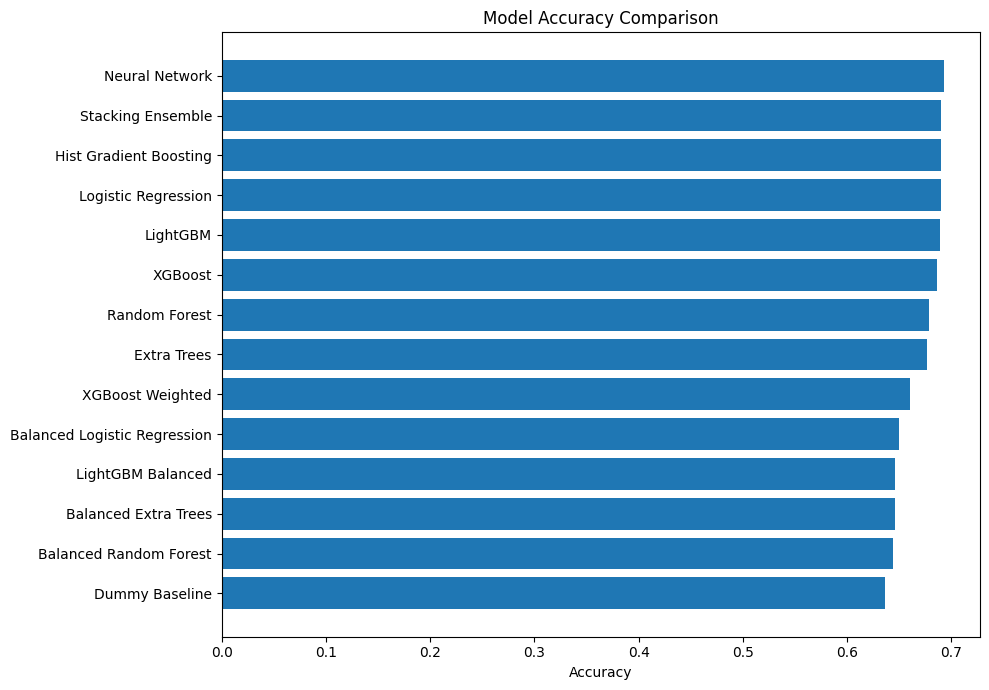

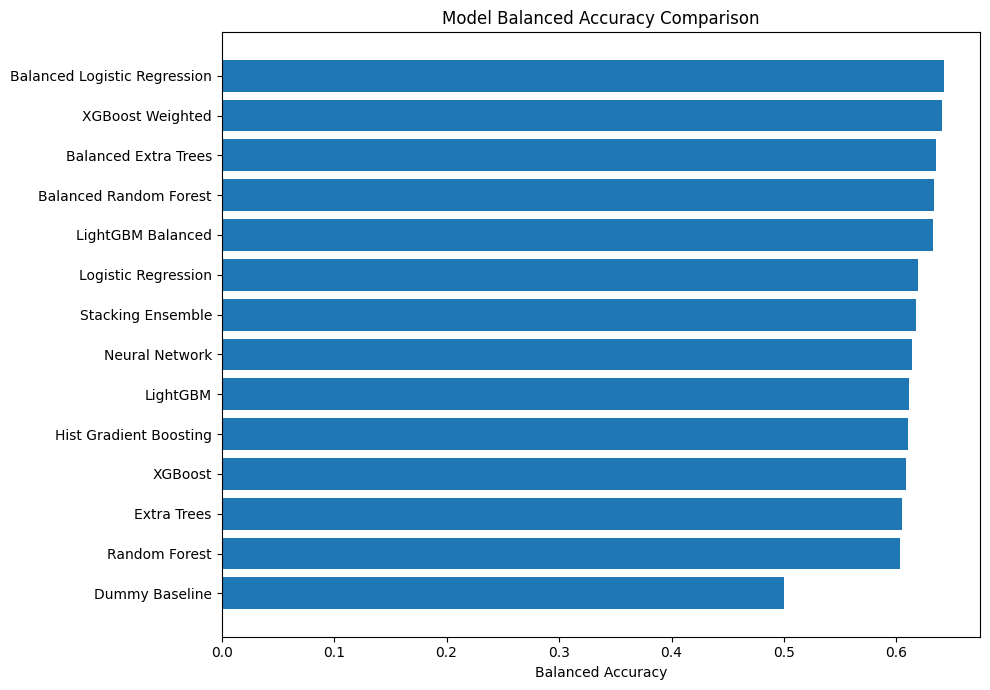

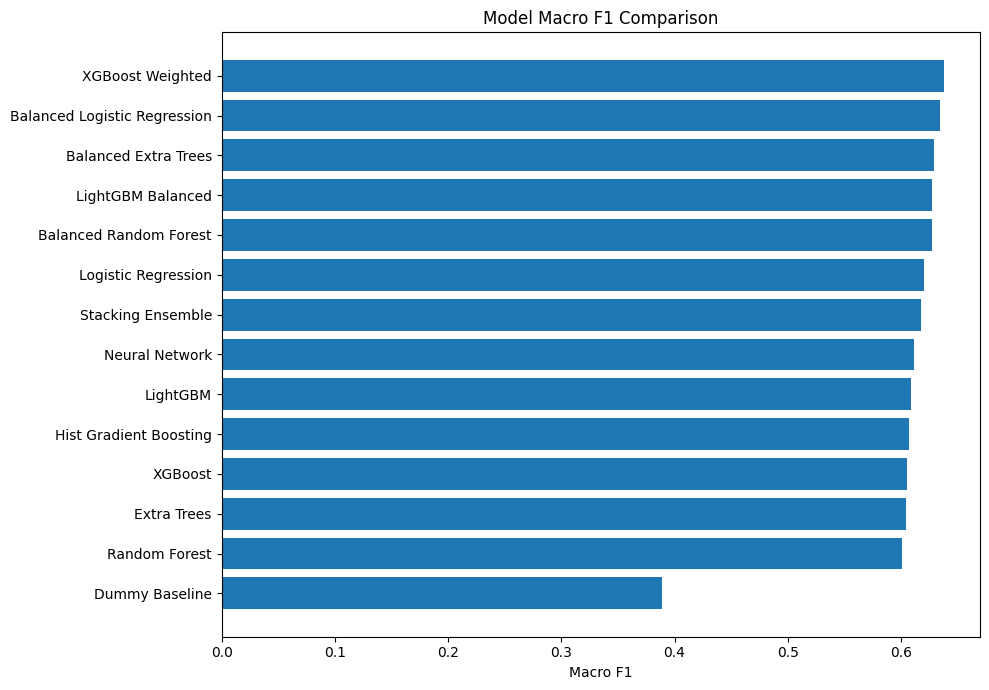


Best raw accuracy model: Neural Network
Best balanced accuracy model: Balanced Logistic Regression

BEST THRESHOLD BY ACCURACY
 threshold  accuracy  balanced_accuracy  macro_f1  class_0_recall  class_1_recall
      0.50    0.6928           0.613751  0.611615        0.323982        0.903520
      0.49    0.6928           0.612218  0.609253        0.316832        0.907605
      0.48    0.6920           0.609586  0.605432        0.307481        0.911691
      0.51    0.6918           0.614026  0.612402        0.328933        0.899120
      0.53    0.6914           0.620550  0.621795        0.360836        0.880264
      0.52    0.6902           0.615009  0.614387        0.339384        0.890635
      0.54    0.6898           0.620118  0.621576        0.364686        0.875550
      0.46    0.6896           0.601452  0.592991        0.278328        0.924576
      0.45    0.6896           0.600391  0.591103        0.273377        0.927404
      0.55    0.6896           0.625620  0.628625   

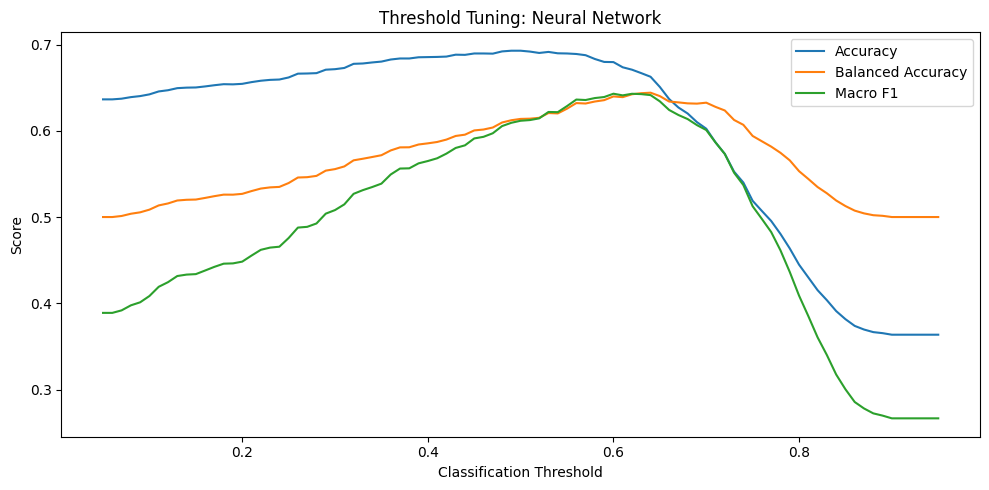

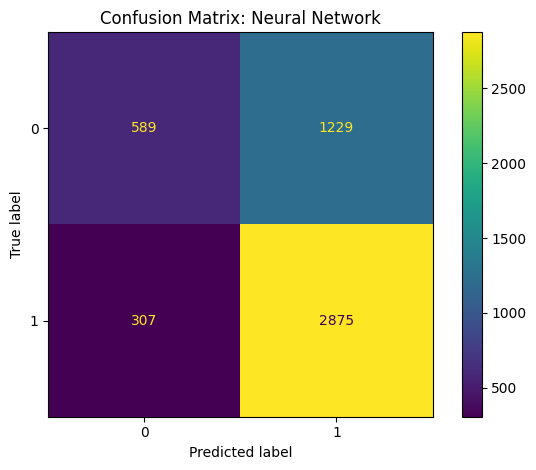

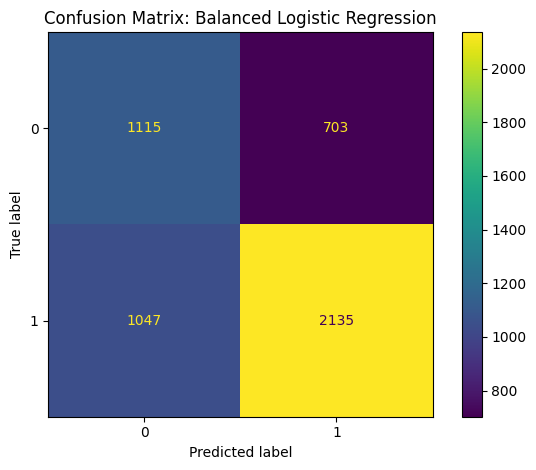


Saved results to: /Users/sohumpulijal/Documents/school/CS189/project/model_results_full_comparison.csv


In [25]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# 1. Load data
# ============================================================

BASE_DIR = Path("/Users/sohumpulijal/Documents/school/CS189/project")

TRAIN_PATH = BASE_DIR / "monkeypox_project_data_cleaning" / "data" / "processed" / "train.csv"
TEST_PATH = BASE_DIR / "monkeypox_project_data_cleaning" / "data" / "processed" / "test.csv"
TARGET_PATH = BASE_DIR / "monkeypox_project_data_cleaning" / "data" / "processed" / "target_column.txt"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

with open(TARGET_PATH, "r") as file:
    target_column = file.read().strip()

print("Target column:", target_column)
print("Original train shape:", train_df.shape)
print("Original test shape:", test_df.shape)


# ============================================================
# 2. Feature engineering
# ============================================================

def add_engineered_features_clean(df, target_column):
    df = df.copy()

    # Original raw binary symptom/risk columns only
    symptom_cols = [
        "rectal_pain",
        "sore_throat",
        "penile_oedema",
        "oral_lesions",
        "solitary_lesion",
        "swollen_tonsils"
    ]

    risk_cols = [
        "hiv_infection",
        "sexually_transmitted_infection"
    ]

    systemic_cols = [
        "systemic_illness_fever",
        "systemic_illness_muscle_aches_and_pain",
        "systemic_illness_swollen_lymph_nodes"
    ]

    missing_systemic_col = "systemic_illness_none_reported_or_missing"

    symptom_cols = [col for col in symptom_cols if col in df.columns]
    risk_cols = [col for col in risk_cols if col in df.columns]
    systemic_cols = [col for col in systemic_cols if col in df.columns]

    # Clean counts
    df["symptom_count"] = df[symptom_cols].sum(axis=1)
    df["risk_count"] = df[risk_cols].sum(axis=1)
    df["systemic_symptom_count"] = df[systemic_cols].sum(axis=1)

    if missing_systemic_col in df.columns:
        df["has_reported_systemic_illness"] = 1 - df[missing_systemic_col]
    else:
        df["has_reported_systemic_illness"] = (df["systemic_symptom_count"] > 0).astype(int)

    df["total_clinical_features"] = (
        df["symptom_count"] +
        df["risk_count"] +
        df["systemic_symptom_count"]
    )

    # Grouped symptom counts
    lesion_cols = [col for col in ["oral_lesions", "solitary_lesion"] if col in df.columns]
    throat_cols = [col for col in ["sore_throat", "swollen_tonsils"] if col in df.columns]

    df["lesion_count"] = df[lesion_cols].sum(axis=1)
    df["throat_symptom_count"] = df[throat_cols].sum(axis=1)

    # Interaction features
    if "hiv_infection" in df.columns and "sexually_transmitted_infection" in df.columns:
        df["hiv_and_sti"] = df["hiv_infection"] * df["sexually_transmitted_infection"]

    if "rectal_pain" in df.columns and "sexually_transmitted_infection" in df.columns:
        df["rectal_pain_and_sti"] = df["rectal_pain"] * df["sexually_transmitted_infection"]

    if "oral_lesions" in df.columns and "sore_throat" in df.columns:
        df["oral_lesions_and_sore_throat"] = df["oral_lesions"] * df["sore_throat"]

    if "swollen_tonsils" in df.columns and "sore_throat" in df.columns:
        df["tonsils_and_sore_throat"] = df["swollen_tonsils"] * df["sore_throat"]

    if "penile_oedema" in df.columns and "rectal_pain" in df.columns:
        df["penile_oedema_and_rectal_pain"] = df["penile_oedema"] * df["rectal_pain"]

    if "systemic_illness_fever" in df.columns and "hiv_infection" in df.columns:
        df["fever_and_hiv"] = df["systemic_illness_fever"] * df["hiv_infection"]

    if "systemic_illness_swollen_lymph_nodes" in df.columns and "hiv_infection" in df.columns:
        df["systemic_nodes_and_hiv"] = df["systemic_illness_swollen_lymph_nodes"] * df["hiv_infection"]

    # Buckets based on clean clinical count
    df["low_clinical_count"] = (df["total_clinical_features"] <= 2).astype(int)

    df["medium_clinical_count"] = (
        (df["total_clinical_features"] >= 3) &
        (df["total_clinical_features"] <= 5)
    ).astype(int)

    df["high_clinical_count"] = (df["total_clinical_features"] >= 6).astype(int)

    return df


train_fe = add_engineered_features_clean(train_df, target_column)
test_fe = add_engineered_features_clean(test_df, target_column)

X_train = train_fe.drop(columns=[target_column])
y_train = train_fe[target_column]

X_test = test_fe.drop(columns=[target_column])
y_test = test_fe[target_column]

print("Engineered train shape:", X_train.shape)
print("Engineered test shape:", X_test.shape)

print("\nClass balance:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

baseline_accuracy = y_test.value_counts(normalize=True).max()
print("\nBaseline accuracy:", round(baseline_accuracy, 4))


# ============================================================
# 3. Define models
# ============================================================

models = {}

models["Dummy Baseline"] = DummyClassifier(strategy="most_frequent")

models["Logistic Regression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

models["Balanced Logistic Regression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

models["Random Forest"] = RandomForestClassifier(
    n_estimators=700,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

models["Balanced Random Forest"] = RandomForestClassifier(
    n_estimators=700,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

models["Extra Trees"] = ExtraTreesClassifier(
    n_estimators=700,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

models["Balanced Extra Trees"] = ExtraTreesClassifier(
    n_estimators=700,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

models["Hist Gradient Boosting"] = HistGradientBoostingClassifier(
    max_iter=600,
    learning_rate=0.03,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    random_state=42
)

models["Neural Network"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

# XGBoost
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=700,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    # Since class 1 is over-predicted, this version reduces class 1 weight.
    models["XGBoost Weighted"] = XGBClassifier(
        n_estimators=700,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=0.57,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    print("\nXGBoost installed and added.")

except ImportError:
    print("\nXGBoost is not installed.")
    print("Install with: python -m pip install xgboost")

# LightGBM
try:
    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    models["LightGBM Balanced"] = LGBMClassifier(
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    print("LightGBM installed and added.")

except ImportError:
    print("\nLightGBM is not installed.")
    print("Install with: python -m pip install lightgbm")


# Stacking Ensemble
models["Stacking Ensemble"] = StackingClassifier(
    estimators=[
        ("lr", Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, random_state=42))
        ])),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )),
        ("hgb", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5,
    n_jobs=-1
)


# ============================================================
# 4. Train and evaluate
# ============================================================

results = []
trained_models = {}

for model_name, model in models.items():
    print("\n==============================")
    print(model_name)
    print("==============================")

    model.fit(X_train, y_train)
    trained_models[model_name] = model

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    balanced_accuracy = balanced_accuracy_score(y_test, predictions)
    macro_f1 = f1_score(y_test, predictions, average="macro")
    weighted_f1 = f1_score(y_test, predictions, average="weighted")
    class_0_recall = recall_score(y_test, predictions, pos_label=0)
    class_1_recall = recall_score(y_test, predictions, pos_label=1)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, probabilities)
        pr_auc = average_precision_score(y_test, probabilities)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Weighted F1:       {weighted_f1:.4f}")
    print(f"Class 0 Recall:    {class_0_recall:.4f}")
    print(f"Class 1 Recall:    {class_1_recall:.4f}")
    print(f"ROC-AUC:           {roc_auc:.4f}")
    print(f"PR-AUC:            {pr_auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nClassification Report:")
    print(classification_report(y_test, predictions, zero_division=0))

    results.append({
        "model": model_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "class_0_recall": class_0_recall,
        "class_1_recall": class_1_recall,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })


results_df = pd.DataFrame(results)

print("\n==============================")
print("MODEL COMPARISON BY ACCURACY")
print("==============================")
print(
    results_df.sort_values(
        by="accuracy",
        ascending=False
    ).to_string(index=False)
)

print("\n==============================")
print("MODEL COMPARISON BY BALANCED ACCURACY")
print("==============================")
print(
    results_df.sort_values(
        by="balanced_accuracy",
        ascending=False
    ).to_string(index=False)
)

print("\n==============================")
print("MODEL COMPARISON BY MACRO F1")
print("==============================")
print(
    results_df.sort_values(
        by="macro_f1",
        ascending=False
    ).to_string(index=False)
)


# ============================================================
# 5. Charts
# ============================================================

accuracy_df = results_df.sort_values(by="accuracy", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(accuracy_df["model"], accuracy_df["accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

balanced_df = results_df.sort_values(by="balanced_accuracy", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(balanced_df["model"], balanced_df["balanced_accuracy"])
plt.xlabel("Balanced Accuracy")
plt.title("Model Balanced Accuracy Comparison")
plt.tight_layout()
plt.show()

macro_f1_df = results_df.sort_values(by="macro_f1", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(macro_f1_df["model"], macro_f1_df["macro_f1"])
plt.xlabel("Macro F1")
plt.title("Model Macro F1 Comparison")
plt.tight_layout()
plt.show()


# ============================================================
# 6. Pick best models
# ============================================================

best_accuracy_model_name = results_df.sort_values(
    by="accuracy",
    ascending=False
).iloc[0]["model"]

best_balanced_model_name = results_df.sort_values(
    by="balanced_accuracy",
    ascending=False
).iloc[0]["model"]

print("\nBest raw accuracy model:", best_accuracy_model_name)
print("Best balanced accuracy model:", best_balanced_model_name)


# ============================================================
# 7. Threshold tuning for best accuracy model
# ============================================================

best_model = trained_models[best_accuracy_model_name]

if hasattr(best_model, "predict_proba"):
    probabilities = best_model.predict_proba(X_test)[:, 1]

    threshold_results = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        threshold_predictions = (probabilities >= threshold).astype(int)

        threshold_results.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, threshold_predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, threshold_predictions),
            "macro_f1": f1_score(y_test, threshold_predictions, average="macro"),
            "class_0_recall": recall_score(y_test, threshold_predictions, pos_label=0),
            "class_1_recall": recall_score(y_test, threshold_predictions, pos_label=1)
        })

    threshold_df = pd.DataFrame(threshold_results)

    print("\n==============================")
    print("BEST THRESHOLD BY ACCURACY")
    print("==============================")
    print(
        threshold_df.sort_values(
            by="accuracy",
            ascending=False
        ).head(10).to_string(index=False)
    )

    print("\n==============================")
    print("BEST THRESHOLD BY BALANCED ACCURACY")
    print("==============================")
    print(
        threshold_df.sort_values(
            by="balanced_accuracy",
            ascending=False
        ).head(10).to_string(index=False)
    )

    plt.figure(figsize=(10, 5))
    plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
    plt.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], label="Balanced Accuracy")
    plt.plot(threshold_df["threshold"], threshold_df["macro_f1"], label="Macro F1")
    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Tuning: {best_accuracy_model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 8. Confusion matrix for best models
# ============================================================

for name in [best_accuracy_model_name, best_balanced_model_name]:
    model = trained_models[name]
    predictions = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()


# ============================================================
# 9. Save results
# ============================================================

OUTPUT_PATH = BASE_DIR / "model_results_full_comparison.csv"
results_df.to_csv(OUTPUT_PATH, index=False)

print("\nSaved results to:", OUTPUT_PATH)

In [17]:
print('done')

done


In [21]:
!brew install libomp

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/core/portable-ruby/blobs/sha256:4ba8d535df01e4bf97e6661c3815796fd77364ea2552606e891659133a76f0e1
######################################################################### 100.0%
==> Pouring portable-ruby-4.0.5_1.arm64_big_sur.bottle.tar.gz
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
aube: Fast Node.js package manager
btdu: Sampling disk usage profiler for btrfs
bumblebee: Read-only developer endpoint scanner for supply-chain exposure
cc-switch-cli: All-in-one assistant tool for Claude Code, Codex, Gemini, OpenCode and OpenClaw
chunkah: OCI building tool for content-based layers
cloudmonkey: Apache CloudStack CloudMonkey CLI
codeburn: See where your AI coding tokens go - by task, tool, model,

In [26]:
real_systemic_cols = [
    "systemic_illness_fever",
    "systemic_illness_muscle_aches_and_pain",
    "systemic_illness_none_reported_or_missing",
    "systemic_illness_swollen_lymph_nodes"
]

real_systemic_cols = [col for col in real_systemic_cols if col in train_fe.columns]

print("Real systemic illness row-sum counts:")
print(train_fe[real_systemic_cols].sum(axis=1).value_counts().sort_index())

print("\nClean clinical features summary:")
print(train_fe["total_clinical_features"].describe())

print("\nClean clinical features by target:")
print(
    train_fe.groupby(target_column)["total_clinical_features"]
    .describe()
)

Real systemic illness row-sum counts:
1    20000
Name: count, dtype: int64

Clean clinical features summary:
count    20000.000000
mean         4.756850
std          1.484533
min          0.000000
25%          4.000000
50%          5.000000
75%          6.000000
max          9.000000
Name: total_clinical_features, dtype: float64

Clean clinical features by target:
             count      mean       std  min  25%  50%  75%  max
monkeypox                                                      
0           7273.0  4.271552  1.482604  0.0  3.0  4.0  5.0  9.0
1          12727.0  5.034179  1.412716  1.0  4.0  5.0  6.0  9.0
